<a href="https://colab.research.google.com/github/youwins-lab/Blog/blob/main/ch06/quantization_3way_300.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q vllm
!python -V && pip list 2>/dev/null | grep -E "^vllm|^torch "
!wget -q https://huggingface.co/datasets/anon8231489123/ShareGPT_Vicuna_unfiltered/resolve/main/ShareGPT_V3_unfiltered_cleaned_split.json
!nvidia-smi --query-gpu=name,driver_version --format=csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.9/312.9 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358

In [4]:
!pip uninstall -y -q torchaudio torchvision
!vllm --version
!pip freeze | grep vllm

0.27.1
vllm==0.27.1


In [5]:
!nvidia-smi

Sat Aug 22 15:13:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!wget https://huggingface.co/datasets/anon8231489123/ShareGPT_Vicuna_unfiltered/resolve/main/ShareGPT_V3_unfiltered_cleaned_split.json
!git clone https://github.com/vllm-project/vllm.git

--2026-08-22 15:14:32--  https://huggingface.co/datasets/anon8231489123/ShareGPT_Vicuna_unfiltered/resolve/main/ShareGPT_V3_unfiltered_cleaned_split.json
Resolving huggingface.co (huggingface.co)... 13.35.202.40, 13.35.202.97, 13.35.202.34, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.40|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/642912f7a760fe0bf37996b1/d7094af68bb58022696728841937d7285db423eba9d055b3386797b28db2cbdb?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27ShareGPT_V3_unfiltered_cleaned_split.json%3B+filename%3D%22ShareGPT_V3_unfiltered_cleaned_split.json%22%3B&response-content-type=application%2Fjson&user_id=public&X-Xet-Cas-Uid=public&Expires=1787415272&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjQyOTEyZjdhNzYwZmUwYmYzNzk5NmIxL2Q3MDk0YWY2OGJiNTgwMjI2OTY3Mjg4NDE5MzdkNzI4NWRiNDIzZWJhOWQwNTViMzM4Njc5N2IyOGRiMmNiZGJcXD9yZXNw

In [7]:
!ls -lh /content/ShareGPT_V3*.json*

-rw-r--r-- 1 root root 642M Aug 22 15:11 /content/ShareGPT_V3_unfiltered_cleaned_split.json
-rw-r--r-- 1 root root 642M Aug 22 15:14 /content/ShareGPT_V3_unfiltered_cleaned_split.json.1


In [8]:
hf_model_id = "Qwen/Qwen2.5-7B-Instruct"

In [9]:
!nohup vllm serve {hf_model_id} --max-model-len 4096 > vllm.log 2>&1 &

In [69]:
!du -sh ~/.cache/huggingface/hub 2>/dev/null; nvidia-smi --query-gpu=memory.used --format=csv

15G	/root/.cache/huggingface/hub
memory.used [MiB]
14946 MiB


In [76]:
!tail -40 vllm.log

(APIServer pid=10637)     return func(*args, **kwargs)
(APIServer pid=10637)   File "/usr/local/lib/python3.13/dist-packages/vllm/v1/engine/core_client.py", line 139, in make_async_mp_client
(APIServer pid=10637)     return AsyncMPClient(*client_args)
(APIServer pid=10637)   File "/usr/local/lib/python3.13/dist-packages/vllm/tracing/otel.py", line 178, in sync_wrapper
(APIServer pid=10637)     return func(*args, **kwargs)
(APIServer pid=10637)   File "/usr/local/lib/python3.13/dist-packages/vllm/v1/engine/core_client.py", line 987, in __init__
(APIServer pid=10637)     super().__init__(
(APIServer pid=10637)     ~~~~~~~~~~~~~~~~^
(APIServer pid=10637)         asyncio_mode=True,
(APIServer pid=10637)         ^^^^^^^^^^^^^^^^^^
(APIServer pid=10637)     ...<3 lines>...
(APIServer pid=10637)         client_addresses=client_addresses,
(APIServer pid=10637)         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(APIServer pid=10637)     )
(APIServer pid=10637)     ^
(APIServer pid=10637)   File "/usr/l

In [77]:
!grep -A5 "kernel_warmup" vllm.log | tail -30

(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     kernel_warmup(self)
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     ~~~~~~~~~~~~~^^^^^^
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]   File "/usr/local/lib/python3.13/dist-packages/vllm/model_executor/warmup/kernel_warmup.py", line 100, in kernel_warmup
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     from vllm.model_executor.warmup.minimax_m3_msa_warmup import (
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]         minimax_m3_msa_warmup,
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     )
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]   File "/usr/local/lib/python3.13/dist-packages/vllm/model_executor/warmup/minimax_m3_msa_warmup.py", line 7, in <module>
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     from vllm.models.minimax_m3.nvidia.model import MiniMaxM3SparseAttention
--
(EngineCore pid=10804)     kernel_warmup(self)
(Engin

In [78]:
!grep "EngineCore pid" vllm.log | grep -iE "error|Error:" | tail -15

(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     from .nvidia.model import (
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     ...<2 lines>...
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     )
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]   File "/usr/local/lib/python3.13/dist-packages/vllm/models/minimax_m3/nvidia/model.py", line 74, in <module>
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     from vllm.models.minimax_m3.common.mm_preprocess import (
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     ...<3 lines>...
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     )
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]   File "/usr/local/lib/python3.13/dist-packages/vllm/models/minimax_m3/common/mm_preprocess.py", line 43, in <module>
(EngineCore pid=10804) ERROR 08-22 15:22:59 [core.py:1349]     from vllm.transformers_utils.processors.minimax_m3 import (
(EngineCore pid=10804) ERROR 08

In [75]:
!grep -iE "error|traceback|raise|failed|out of memory|CUDA" vllm.log | head -40

(APIServer pid=10637) WARNING 08-22 15:22:25 [vllm.py:1194] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(APIServer pid=10637) INFO 08-22 15:22:25 [vllm.py:1426] Cudagraph is disabled under eager mode
(EngineCore pid=10804) INFO 08-22 15:22:43 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='Qwen/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs

In [79]:
!pip install -q torchvision --index-url https://download.pytorch.org/whl/cu130
!python -c "import torchvision; print(torchvision.__version__)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 115.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.27.1 requires torchaudio==2.11.0, which is not installed.
0.28.0+cu130


In [81]:
!pkill -f "vllm serve"; sleep 5
!rm -f vllm.log
!nohup vllm serve {hf_model_id} --max-model-len 4096 --enforce-eager > vllm.log 2>&1 &

^C


In [100]:
!ps aux | grep "vllm serve" | grep -v grep | wc -l

1


In [103]:
!tail -20 vllm.log

(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/messages, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/messages/count_tokens, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /generative_scoring, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /scale_elastic_ep, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /is_scaling_elastic_ep, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route: /v1/chat/completions/render, Methods: POST
(APIServer pid=12296) INFO 08-22 15:29:42 [launcher.py:46] Route:

In [102]:
!curl -s -o /dev/null -w "%{http_code}\n" http://127.0.0.1:8000/health

200


In [104]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 20 --max-concurrency 1 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x783f08dfefc0>, trust_remote_code=False, seed=0, num_prompts=20, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [106]:
!grep -iE "KV cache|concurrenc|model loading|attention backend|Free memory" vllm.log | tee -a kv_notes.txt
!cat vllm_bench.json | python3 -m json.tool 2>/dev/null | head -40

(EngineCore pid=12457) INFO 08-22 15:27:36 [cuda.py:482] Using FLASH_ATTN attention backend out of potential backends: ['FLASH_ATTN', 'FLASHINFER', 'TRITON_ATTN', 'FLEX_ATTENTION'].
(EngineCore pid=12457) INFO 08-22 15:27:43 [model_runner.py:329] Model loading took 14.29 GiB and 8.857105 seconds
(EngineCore pid=12457) INFO 08-22 15:27:46 [gpu_worker.py:563] Available KV cache memory: 5.46 GiB
(EngineCore pid=12457) INFO 08-22 15:27:46 [kv_cache_utils.py:2235] GPU KV cache size: 102,288 tokens
(EngineCore pid=12457) INFO 08-22 15:27:46 [kv_cache_utils.py:2236] Maximum concurrency for 4,096 tokens per request: 24.97x
(EngineCore pid=12457) INFO 08-22 15:27:46 [gpu_worker.py:789] Free memory on device (21.84/22.03 GiB) on startup. Desired GPU memory utilization is (0.92, 20.27 GiB). Actual usage is 14.54 GiB for consumed memory (weights + non-torch), 0.27 GiB for peak activation, and 0.0 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=5708521780` (5

In [107]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 50 --max-concurrency 10 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7d002d4a3600>, trust_remote_code=False, seed=0, num_prompts=50, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [110]:
!grep -iE "Waiting: [1-9]|preempt|cache usage: [5-9][0-9]" vllm.log | tail -10

In [109]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 200 --max-concurrency 100 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7fcb2f142de0>, trust_remote_code=False, seed=0, num_prompts=200, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_

In [111]:
!grep -iE "preempt|Waiting" vllm.log | tail -20

(APIServer pid=12296) INFO 08-22 15:35:43 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.6 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 0.0%
(APIServer pid=12296) INFO 08-22 15:35:53 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 0.0 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 0.0%
(APIServer pid=12296) INFO 08-22 15:39:43 [loggers.py:310] Engine 000: Avg prompt throughput: 10.8 tokens/s, Avg generation throughput: 63.7 tokens/s, Running: 10 reqs, Waiting: 0 reqs, GPU KV cache usage: 2.1%, Prefix cache hit rate: 32.2%
(APIServer pid=12296) INFO 08-22 15:39:53 [loggers.py:310] Engine 000: Avg prompt throughput: 5.6 tokens/s, Avg generation throughput: 166.6 tokens/s, Running: 9 reqs, Waiting: 0 reqs, GPU KV cache usage: 2.6%, Prefix cache hit rate: 43.8%
(APIServer pid=12296) INFO 08-22 15:40:03 [lo

In [112]:
!pkill -f "vllm serve"; sleep 10
!ps aux | grep "vllm serve" | grep -v grep | wc -l

^C
1


In [113]:
hf_model_id = "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4"

In [114]:
!rm -f vllm.log
!nohup vllm serve {hf_model_id} --max-model-len 4096 --enforce-eager > vllm.log 2>&1 &

In [129]:
!tail -20 vllm.log

(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/chat/completions/batch, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/responses, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/messages, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /v1/messages/count_tokens, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /generative_scoring, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /scale_elastic_ep, Methods: POST
(APIServer pid=19222) INFO 08-22 15:52:30 [launcher.py:46] Route: /is_scali

In [130]:
!curl -s -o /dev/null -w "%{http_code}\n" http://127.0.0.1:8000/health

200


In [131]:
!grep -iE "KV cache|concurrenc|Model loading|attention backend|quantization|Marlin|gptq" vllm.log | tee -a kv_notes.txt

(APIServer pid=19222) INFO 08-22 15:51:21 [api_utils.py:345]   █▄█▀ █     █     █     █  model   Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4
(APIServer pid=19222) INFO 08-22 15:51:21 [api_utils.py:273] non-default args: {'model_tag': 'Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4', 'model': 'Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4', 'max_model_len': 4096, 'enforce_eager': True}
(EngineCore pid=19441) INFO 08-22 15:51:46 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=auto_gptq, quantization_config=None, enforce_eager=True

In [132]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 20 --max-concurrency 1 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7d28bcb3ae80>, trust_remote_code=False, seed=0, num_prompts=20, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [133]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 50 --max-concurrency 10 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x79611b3236a0>, trust_remote_code=False, seed=0, num_prompts=50, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [134]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 200 --max-concurrency 100 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7e3728992de0>, trust_remote_code=False, seed=0, num_prompts=200, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_

In [135]:
!pkill -f "vllm serve"; sleep 10

^C


In [136]:
hf_model_id = "RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic"

In [137]:
!rm -f vllm.log
!nohup vllm serve {hf_model_id} --max-model-len 4096 --enforce-eager > vllm.log 2>&1 &

In [156]:
!tail -20 vllm.log

(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/chat/completions/batch, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/responses, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/messages, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /v1/messages/count_tokens, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /generative_scoring, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /scale_elastic_ep, Methods: POST
(APIServer pid=22288) INFO 08-22 16:02:12 [launcher.py:46] Route: /is_scali

In [157]:
!grep -iE "KV cache|concurrenc|Model loading|quantization|fp8|cutlass|Kernel|attention backend" vllm.log | tee -a kv_notes.txt

(APIServer pid=22288) INFO 08-22 16:00:52 [api_utils.py:345]   █▄█▀ █     █     █     █  model   RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic
(APIServer pid=22288) INFO 08-22 16:00:52 [api_utils.py:273] non-default args: {'model_tag': 'RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic', 'model': 'RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic', 'max_model_len': 4096, 'enforce_eager': True}
(APIServer pid=22288) INFO 08-22 16:00:55 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])
(EngineCore pid=22538) INFO 08-22 16:01:19 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic', speculative_config=None, tokenizer='RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=a

In [158]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 20 --max-concurrency 1 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f994956ede0>, trust_remote_code=False, seed=0, num_prompts=20, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [159]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 50 --max-concurrency 10 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7a5c0773b6a0>, trust_remote_code=False, seed=0, num_prompts=50, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_r

In [160]:
!vllm bench serve --backend vllm --model {hf_model_id} \
  --endpoint /v1/completions --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 200 --max-concurrency 100 --temperature 0 \
  --save-result --append-result --result-filename vllm_bench.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7f3b0f44b6a0>, trust_remote_code=False, seed=0, num_prompts=200, dataset_name='sharegpt', no_stream=False, dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=128, random_range_

/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4574/4127222528.py:61: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_la

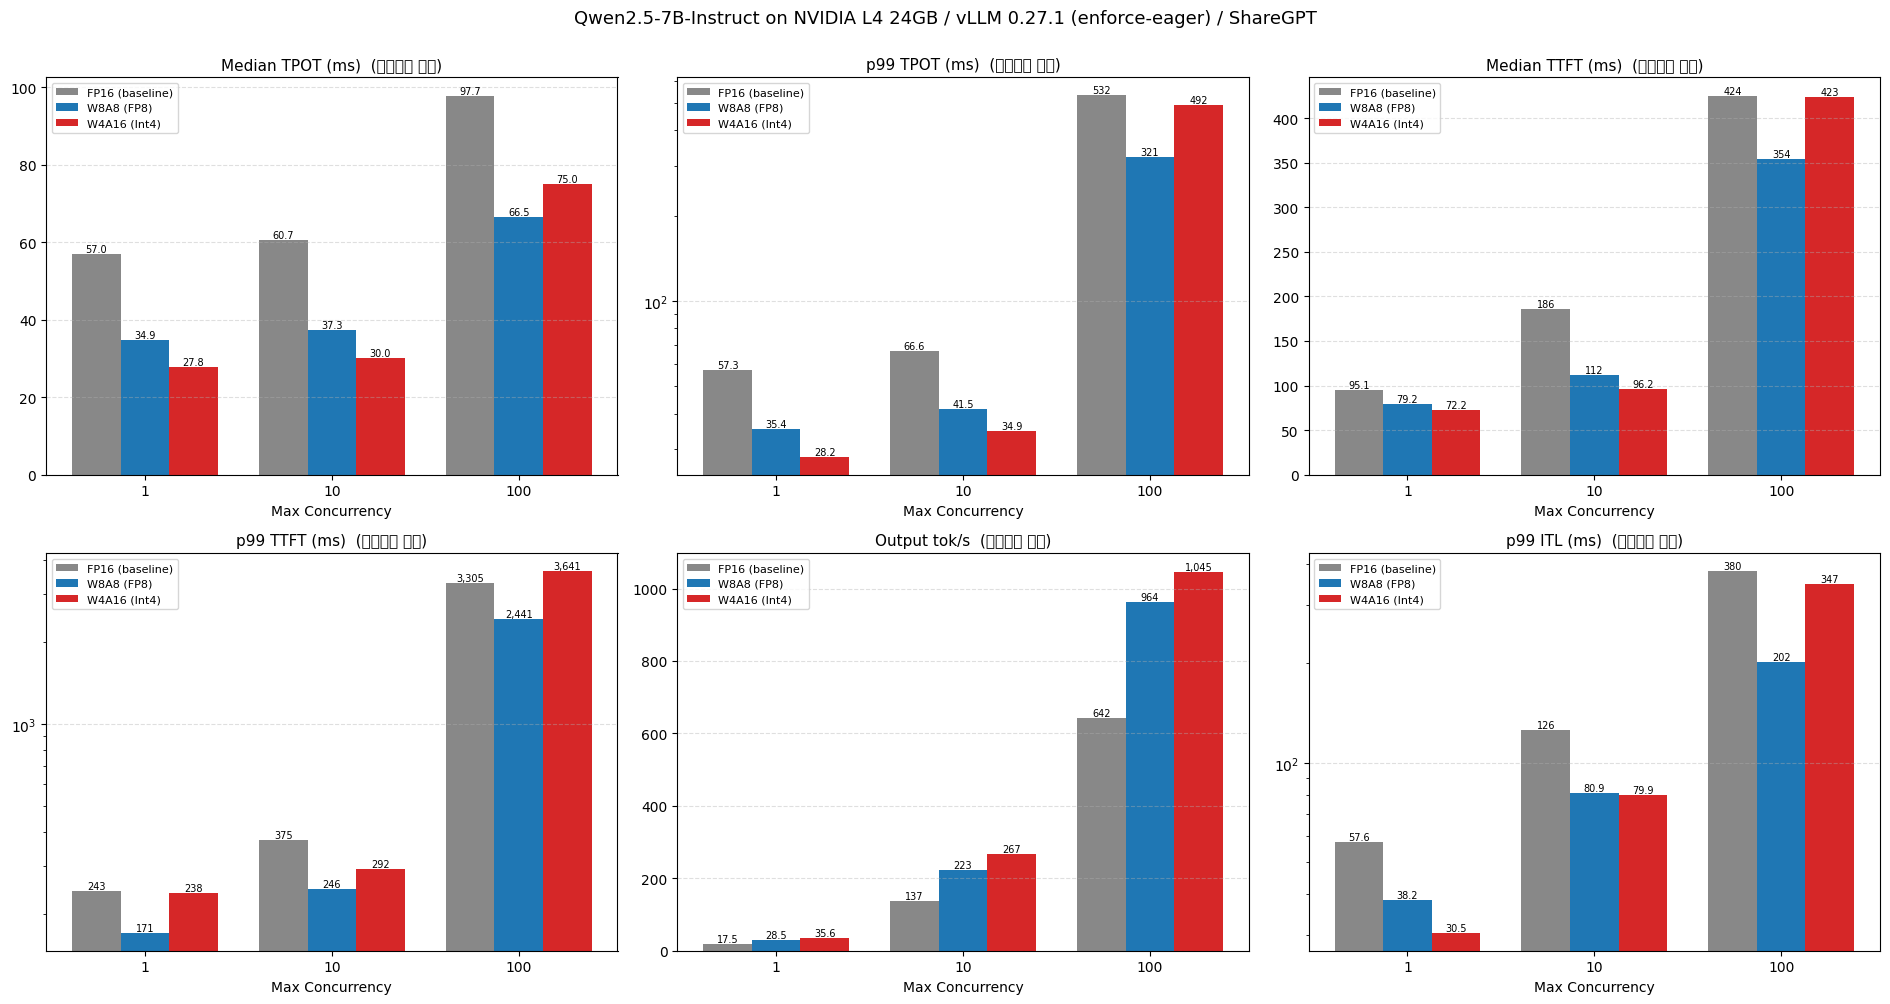


| 정밀도 | conc | median TTFT | p99 TTFT | median TPOT | p99 TPOT | 출력 tok/s |
|---|---|---|---|---|---|---|
| FP16 (baseline) | 1 | 95.10 | 243.28 | 57.03 | 57.25 | 17.46 |
| FP16 (baseline) | 10 | 185.67 | 374.80 | 60.68 | 66.59 | 136.95 |
| FP16 (baseline) | 100 | 424.41 | 3,305.03 | 97.72 | 531.82 | 642.29 |
| W8A8 (FP8) | 1 | 79.15 | 170.66 | 34.91 | 35.36 | 28.47 |
| W8A8 (FP8) | 10 | 111.87 | 246.31 | 37.27 | 41.49 | 223.30 |
| W8A8 (FP8) | 100 | 353.78 | 2,441.34 | 66.52 | 321.48 | 963.60 |
| W4A16 (Int4) | 1 | 72.24 | 238.42 | 27.79 | 28.21 | 35.55 |
| W4A16 (Int4) | 10 | 96.23 | 291.71 | 30.04 | 34.89 | 266.71 |
| W4A16 (Int4) | 100 | 423.26 | 3,640.94 | 75.05 | 492.34 | 1,044.93 |


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [161]:
# ============================================================
# Colab 셀에 그대로 붙여넣고 실행
# vllm_bench.json (9개 결과) → 그래프 6종 + 마크다운 표
# ============================================================
import json, numpy as np, matplotlib.pyplot as plt

with open("vllm_bench.json") as f:
    data = [json.loads(l) for l in f if l.strip()]

# 표시 이름 / 순서 / 색 고정
ORDER = [
    ("Qwen/Qwen2.5-7B-Instruct",                 "FP16 (baseline)", "#888888"),
    ("RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic", "W8A8 (FP8)",      "#1f77b4"),
    ("Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4",       "W4A16 (Int4)",    "#d62728"),
]
NAME  = {k: v for k, v, _ in ORDER}
COLOR = {v: c for _, v, c in ORDER}
LABELS = [v for _, v, _ in ORDER]

METRICS = [
    ("median_tpot_ms",    "Median TPOT (ms)",    "낮을수록 좋음", False),
    ("p99_tpot_ms",       "p99 TPOT (ms)",       "낮을수록 좋음", True),
    ("median_ttft_ms",    "Median TTFT (ms)",    "낮을수록 좋음", False),
    ("p99_ttft_ms",       "p99 TTFT (ms)",       "낮을수록 좋음", True),
    ("output_throughput", "Output tok/s",        "높을수록 좋음", False),
    ("p99_itl_ms",        "p99 ITL (ms)",        "낮을수록 좋음", True),
]

def collect(key):
    g = {}
    for e in data:
        if key not in e or e["model_id"] not in NAME:
            continue
        g.setdefault(e["max_concurrency"], {})[NAME[e["model_id"]]] = e[key]
    return g

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (key, label, hint, logy) in zip(axes.ravel(), METRICS):
    g = collect(key)
    rates = sorted(g)
    x, w = np.arange(len(rates)), 0.26
    offs = np.linspace(-w, w, len(LABELS))
    for i, m in enumerate(LABELS):
        vals = [g[r].get(m, 0) for r in rates]
        pos = x + offs[i]
        ax.bar(pos, vals, w, label=m, color=COLOR[m])
        for p, v in zip(pos, vals):
            if v:
                ax.text(p, v, f"{v:,.0f}" if v >= 100 else f"{v:.1f}",
                        ha="center", va="bottom", fontsize=7)
    if logy:
        ax.set_yscale("log")          # 꼬리 지표는 로그축이라야 형태가 보임
    ax.set_title(f"{label}  ({hint})", fontsize=11)
    ax.set_xlabel("Max Concurrency")
    ax.set_xticks(x); ax.set_xticklabels(rates)
    ax.grid(True, axis="y", ls="--", alpha=0.4)
    ax.legend(fontsize=8)

fig.suptitle("Qwen2.5-7B-Instruct on NVIDIA L4 24GB / vLLM 0.27.1 (enforce-eager) / ShareGPT",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("quant_bench.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------- 블로그용 마크다운 표 ----------
COLS = [("median_ttft_ms","median TTFT"), ("p99_ttft_ms","p99 TTFT"),
        ("median_tpot_ms","median TPOT"), ("p99_tpot_ms","p99 TPOT"),
        ("output_throughput","출력 tok/s")]

print("\n| 정밀도 | conc | " + " | ".join(c[1] for c in COLS) + " |")
print("|---" * (len(COLS) + 2) + "|")
for _, disp, _ in ORDER:
    for e in sorted((x for x in data if NAME.get(x["model_id"]) == disp),
                    key=lambda x: x["max_concurrency"]):
        vals = " | ".join(f'{e.get(k, float("nan")):,.2f}' for k, _ in COLS)
        print(f'| {disp} | {e["max_concurrency"]} | {vals} |')

# 이미지 다운로드
from google.colab import files
files.download("quant_bench.png")

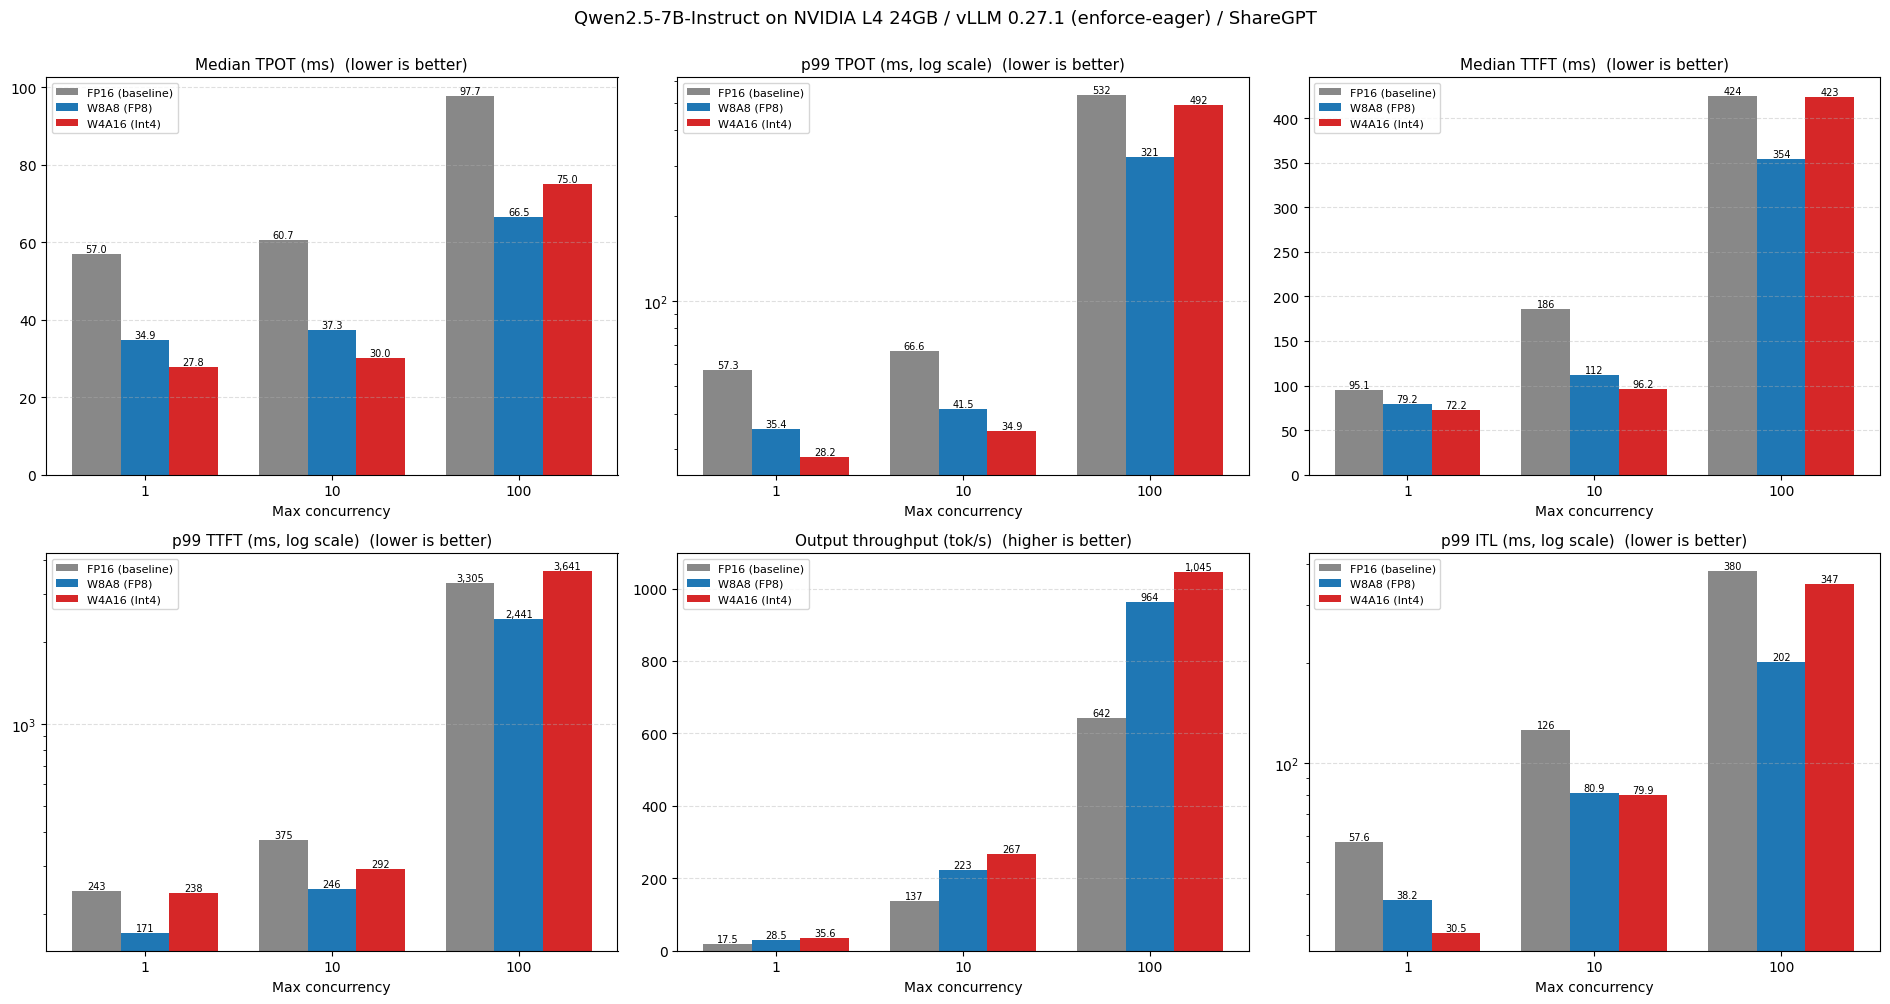


| 정밀도 | conc | median TTFT | p99 TTFT | median TPOT | p99 TPOT | 출력 tok/s |
|---|---|---|---|---|---|---|
| FP16 (baseline) | 1 | 95.10 | 243.28 | 57.03 | 57.25 | 17.46 |
| FP16 (baseline) | 10 | 185.67 | 374.80 | 60.68 | 66.59 | 136.95 |
| FP16 (baseline) | 100 | 424.41 | 3,305.03 | 97.72 | 531.82 | 642.29 |
| W8A8 (FP8) | 1 | 79.15 | 170.66 | 34.91 | 35.36 | 28.47 |
| W8A8 (FP8) | 10 | 111.87 | 246.31 | 37.27 | 41.49 | 223.30 |
| W8A8 (FP8) | 100 | 353.78 | 2,441.34 | 66.52 | 321.48 | 963.60 |
| W4A16 (Int4) | 1 | 72.24 | 238.42 | 27.79 | 28.21 | 35.55 |
| W4A16 (Int4) | 10 | 96.23 | 291.71 | 30.04 | 34.89 | 266.71 |
| W4A16 (Int4) | 100 | 423.26 | 3,640.94 | 75.05 | 492.34 | 1,044.93 |


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [162]:
# ============================================================
# Colab 셀에 그대로 붙여넣고 실행
# vllm_bench.json (9개 결과) → 그래프 6종 + 마크다운 표
# 라벨은 전부 영문 (Colab 한글 폰트 이슈 회피)
# ============================================================
import json, numpy as np, matplotlib.pyplot as plt

with open("vllm_bench.json") as f:
    data = [json.loads(l) for l in f if l.strip()]

# 표시 이름 / 순서 / 색 고정
ORDER = [
    ("Qwen/Qwen2.5-7B-Instruct",                 "FP16 (baseline)", "#888888"),
    ("RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic", "W8A8 (FP8)",      "#1f77b4"),
    ("Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4",       "W4A16 (Int4)",    "#d62728"),
]
NAME   = {k: v for k, v, _ in ORDER}
COLOR  = {v: c for _, v, c in ORDER}
LABELS = [v for _, v, _ in ORDER]

METRICS = [
    ("median_tpot_ms",    "Median TPOT (ms)",         "lower is better",  False),
    ("p99_tpot_ms",       "p99 TPOT (ms, log scale)", "lower is better",  True),
    ("median_ttft_ms",    "Median TTFT (ms)",         "lower is better",  False),
    ("p99_ttft_ms",       "p99 TTFT (ms, log scale)", "lower is better",  True),
    ("output_throughput", "Output throughput (tok/s)","higher is better", False),
    ("p99_itl_ms",        "p99 ITL (ms, log scale)",  "lower is better",  True),
]

def collect(key):
    g = {}
    for e in data:
        if key not in e or e["model_id"] not in NAME:
            continue
        g.setdefault(e["max_concurrency"], {})[NAME[e["model_id"]]] = e[key]
    return g

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (key, label, hint, logy) in zip(axes.ravel(), METRICS):
    g = collect(key)
    rates = sorted(g)
    x, w = np.arange(len(rates)), 0.26
    offs = np.linspace(-w, w, len(LABELS))
    for i, m in enumerate(LABELS):
        vals = [g[r].get(m, 0) for r in rates]
        pos = x + offs[i]
        ax.bar(pos, vals, w, label=m, color=COLOR[m])
        for p, v in zip(pos, vals):
            if v:
                ax.text(p, v, f"{v:,.0f}" if v >= 100 else f"{v:.1f}",
                        ha="center", va="bottom", fontsize=7)
    if logy:
        ax.set_yscale("log")          # 꼬리 지표는 로그축이라야 형태가 보임
    ax.set_title(f"{label}  ({hint})", fontsize=11)
    ax.set_xlabel("Max concurrency")
    ax.set_xticks(x); ax.set_xticklabels(rates)
    ax.grid(True, axis="y", ls="--", alpha=0.4)
    ax.legend(fontsize=8)

fig.suptitle("Qwen2.5-7B-Instruct on NVIDIA L4 24GB / vLLM 0.27.1 (enforce-eager) / ShareGPT",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("quant_bench.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------- 블로그용 마크다운 표 ----------
COLS = [("median_ttft_ms","median TTFT"), ("p99_ttft_ms","p99 TTFT"),
        ("median_tpot_ms","median TPOT"), ("p99_tpot_ms","p99 TPOT"),
        ("output_throughput","출력 tok/s")]

print("\n| 정밀도 | conc | " + " | ".join(c[1] for c in COLS) + " |")
print("|---" * (len(COLS) + 2) + "|")
for _, disp, _ in ORDER:
    for e in sorted((x for x in data if NAME.get(x["model_id"]) == disp),
                    key=lambda x: x["max_concurrency"]):
        vals = " | ".join(f'{e.get(k, float("nan")):,.2f}' for k, _ in COLS)
        print(f'| {disp} | {e["max_concurrency"]} | {vals} |')

# 이미지 다운로드
from google.colab import files
files.download("quant_bench.png")

아래는 예제 원본

In [ ]:
import torch; print(torch.__version__); print(torch.version.cuda)
import time
import vllm
import os

#vllm_dir = os.path.dirname(vllm.__file__)
benchmark_script = "vllm/benchmarks/benchmark_serving.py"

2.6.0+cu124
12.4
INFO 05-17 20:43:18 [__init__.py:239] Automatically detected platform cuda.


In [ ]:
# prompts = [
#     "Who is Lionel Messi?",
#     "How many parameters does BERT-large have?",
#     "What is a Machine Learning Engineer?",
#     "Explain the size of ChatGPT model please",
# ]

In [ ]:
hf_model_id = "Qwen/Qwen2.5-7B-Instruct" # -AWQ

In [ ]:
!nohup vllm serve {hf_model_id} \
       --disable-log-requests \
       --max-model-len 4096 \
       > vllm.log 2>&1 &

In [ ]:
import time
import requests


def check_vllm_status():
  max_retries = 100  # e.g. wait up to 60 seconds (30 x 2s)
  wait_time = 10

  print("⏳ Waiting for vLLM server to become healthy...")

  for i in range(max_retries):
      try:
          r = requests.get("http://127.0.0.1:8000/health")
          if r.ok:
              print("✅ vLLM server is healthy and ready!")
              break
      except Exception as e:
          print(f"Attempt {i+1}: Not ready yet...")

      time.sleep(wait_time)
  else:
      print("❌ Timed out waiting for vLLM server to start.")
  return
check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...
Attempt 2: Not ready yet...
Attempt 3: Not ready yet...
Attempt 4: Not ready yet...
Attempt 5: Not ready yet...
Attempt 6: Not ready yet...
Attempt 7: Not ready yet...
Attempt 8: Not ready yet...
Attempt 9: Not ready yet...
Attempt 10: Not ready yet...
Attempt 11: Not ready yet...
Attempt 12: Not ready yet...
Attempt 13: Not ready yet...
Attempt 14: Not ready yet...
Attempt 15: Not ready yet...
✅ vLLM server is healthy and ready!


In [ ]:
!tail -n 300 vllm.log

INFO 05-17 21:20:41 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:20:42.136630: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747516842.158654   13957 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747516842.165328   13957 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO 05-17 21:20:50 [api_server.py:1043] vLLM API server version 0.8.5.post1
INFO 05-17 21:20:50 [api_server.py:1044] args: Namespace(subparser='serve', model_tag='Qwen/Qwen2.5-7B-Instruct', config='', host=None, port=8000, uvicorn_log_level='info', disable_uvicorn_access_log=False, allow_credentials=False, allowed_origins=['*'], allowed_methods=['*'], allowe

In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 10 \
  --max-concurrency 1 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

INFO 05-17 21:23:12 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:23:12 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:23:12.963145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747516992.984817   14773 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747516992.991432   14773 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=1, model='Qwen/Qwen2.5-7B-Instruct', tokenizer=None, use_beam_sea

In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 10 \
  --max-concurrency 10 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

INFO 05-17 21:26:12 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:26:13 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:26:13.660006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747517173.681628   15613 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747517173.688211   15613 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=10, model='Qwen/Qwen2.5-7B-Instruct', tokenizer=None, use_beam_se

In [ ]:
# !python3 {benchmark_script} \
#   --backend vllm \
#   --model {hf_model_id} \
#   --endpoint /v1/completions \
#   --dataset-name sharegpt \
#   --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
#   --num-prompts 50 \
#   --max-concurrency 50 \
#   --save-result \
#   --append-result \
#   --result-filename vllm_bench.json

In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 100 \
  --max-concurrency 100 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

INFO 05-17 21:27:24 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:27:24 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:27:24.945847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747517244.967824   15967 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747517244.974429   15967 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=100, model='Qwen/Qwen2.5-7B-Instruct', tokenizer=None, use_beam_s

In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 300 \
  --max-concurrency 300 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

INFO 05-17 21:28:46 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:28:47 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:28:47.573535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747517327.594827   16369 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747517327.601308   16369 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=300, model='Qwen/Qwen2.5-7B-Instruct', tokenizer=None, use_beam_s

In [ ]:
!pkill -f "vllm serve" && sleep 10

^C


In [ ]:
!ps aux | grep "vllm serve" | grep -v grep

root       13957  4.7  2.7 13040164 1499736 ?    Sl   21:20   0:27 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen2.5-7B-Instruct --disable-log-requests


In [ ]:
hf_model_id = "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4" # you can try AWQ W4A16 as well

In [ ]:
!nohup vllm serve {hf_model_id} \
       --disable-log-requests \
       > vllm.log 2>&1 &

In [ ]:
check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...
Attempt 2: Not ready yet...
Attempt 3: Not ready yet...
Attempt 4: Not ready yet...
Attempt 5: Not ready yet...
Attempt 6: Not ready yet...
Attempt 7: Not ready yet...
Attempt 8: Not ready yet...
Attempt 9: Not ready yet...
Attempt 10: Not ready yet...
Attempt 11: Not ready yet...
Attempt 12: Not ready yet...
Attempt 13: Not ready yet...
✅ vLLM server is healthy and ready!


In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 10 \
  --max-concurrency 1 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

!python3 {benchmark_script} \
--backend vllm \
--model {hf_model_id} \
--endpoint /v1/completions \
--dataset-name sharegpt \
--dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
--num-prompts 10 \
--max-concurrency 10 \
--save-result \
--append-result \
--result-filename vllm_bench.json

# !python3 {benchmark_script} \
# --backend vllm \
# --model {hf_model_id} \
# --endpoint /v1/completions \
# --dataset-name sharegpt \
# --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
# --num-prompts 50 \
# --max-concurrency 50 \
# --save-result \
# --append-result \
# --result-filename vllm_bench.json

!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 100 \
  --max-concurrency 100 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json


!python3 {benchmark_script} \
--backend vllm \
--model {hf_model_id} \
--endpoint /v1/completions \
--dataset-name sharegpt \
--dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
--num-prompts 300 \
--max-concurrency 300 \
--save-result \
--append-result \
--result-filename vllm_bench.json

INFO 05-17 21:34:06 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:34:06 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:34:07.114615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747517647.138287   17942 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747517647.145064   17942 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=1, model='Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4', tokenizer=None, us

In [ ]:
!pkill -f "vllm serve" && sleep 10

^C


In [ ]:
!ps aux | grep "vllm serve" | grep -v grep

root       16858  5.9  2.6 13043392 1492388 ?    Sl   21:30   0:26 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4 --disable-log-requests


In [ ]:
hf_model_id = "RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic"

In [ ]:
!nohup vllm serve {hf_model_id} \
       --disable-log-requests \
       > vllm.log 2>&1 &

In [ ]:
check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...
Attempt 2: Not ready yet...
Attempt 3: Not ready yet...
Attempt 4: Not ready yet...
Attempt 5: Not ready yet...
Attempt 6: Not ready yet...
Attempt 7: Not ready yet...
Attempt 8: Not ready yet...
Attempt 9: Not ready yet...
Attempt 10: Not ready yet...
Attempt 11: Not ready yet...
Attempt 12: Not ready yet...
Attempt 13: Not ready yet...
Attempt 14: Not ready yet...
✅ vLLM server is healthy and ready!


In [ ]:
!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 10 \
  --max-concurrency 1 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

!python3 {benchmark_script} \
--backend vllm \
--model {hf_model_id} \
--endpoint /v1/completions \
--dataset-name sharegpt \
--dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
--num-prompts 10 \
--max-concurrency 10 \
--save-result \
--append-result \
--result-filename vllm_bench.json

# !python3 {benchmark_script} \
# --backend vllm \
# --model {hf_model_id} \
# --endpoint /v1/completions \
# --dataset-name sharegpt \
# --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
# --num-prompts 50 \
# --max-concurrency 50 \
# --save-result \
# --append-result \
# --result-filename vllm_bench.json

!python3 {benchmark_script} \
  --backend vllm \
  --model {hf_model_id} \
  --endpoint /v1/completions \
  --dataset-name sharegpt \
  --dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
  --num-prompts 100 \
  --max-concurrency 100 \
  --save-result \
  --append-result \
  --result-filename vllm_bench.json

!python3 {benchmark_script} \
--backend vllm \
--model {hf_model_id} \
--endpoint /v1/completions \
--dataset-name sharegpt \
--dataset-path /content/ShareGPT_V3_unfiltered_cleaned_split.json \
--num-prompts 300 \
--max-concurrency 300 \
--save-result \
--append-result \
--result-filename vllm_bench.json

INFO 05-17 21:40:23 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 05-17 21:40:23 [__init__.py:239] Automatically detected platform cuda.
2025-05-17 21:40:23.984921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747518024.006858   19960 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747518024.013458   19960 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Namespace(backend='vllm', base_url=None, host='127.0.0.1', port=8000, endpoint='/v1/completions', dataset_name='sharegpt', dataset_path='/content/ShareGPT_V3_unfiltered_cleaned_split.json', max_concurrency=1, model='RedHatAI/Qwen2.5-7B-Instruct-FP8-dynamic', tokenizer=No

In [ ]:
import matplotlib.pyplot as plt
import json

# Load the JSON lines from a local json saved containing benchmark results
with open("vllm_bench.json", "r") as f:
    data = [json.loads(line) for line in f if line.strip()]



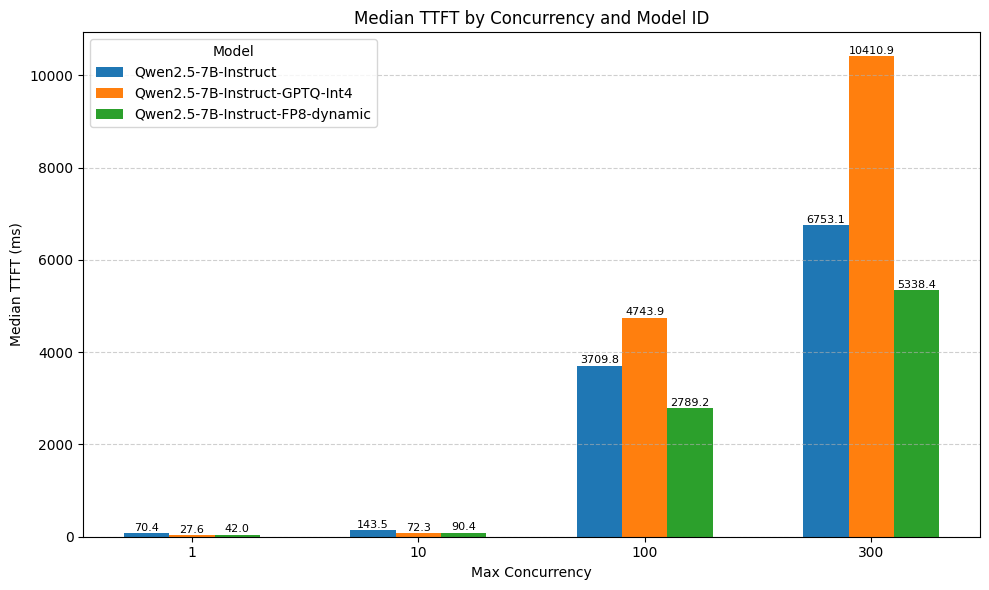

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

# Parse raw data
#raw_data = """<...your data here...>"""  # keep the full string as before
#data = [json.loads(line) for line in raw_data.strip().split('\n')]

# Organize by rate (max_concurrency)
grouped = {}
for entry in data:
    rate = entry["max_concurrency"]
    model = entry["model_id"]
    ttft = entry["median_ttft_ms"]
    if rate not in grouped:
        grouped[rate] = {}
    grouped[rate][model] = ttft

# Sort the group keys (rates) for consistent display
sorted_rates = sorted(grouped.keys())

# Unique models across all groups
all_models = sorted(set(model for group in grouped.values() for model in group))

# Prepare bar positions and heights
bar_width = 0.2
x = np.arange(len(sorted_rates))
offsets = np.linspace(-bar_width*(len(all_models)-1)/2, bar_width*(len(all_models)-1)/2, len(all_models))

plt.figure(figsize=(10, 6))

for i, model in enumerate(all_models):
    ttft_values = [grouped[rate].get(model, 0) for rate in sorted_rates]
    bar_positions = x + offsets[i]
    bars = plt.bar(bar_positions, ttft_values, bar_width, label=model.split("/")[-1])

    # Add text labels above each bar
    for pos, val in zip(bar_positions, ttft_values):
        if val > 0:
            plt.text(pos, val + 10, f"{val:.1f}", ha='center', va='bottom', fontsize=8)


plt.xlabel("Max Concurrency")
plt.ylabel("Median TTFT (ms)")
plt.title("Median TTFT by Concurrency and Model ID")
plt.xticks(x, sorted_rates)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


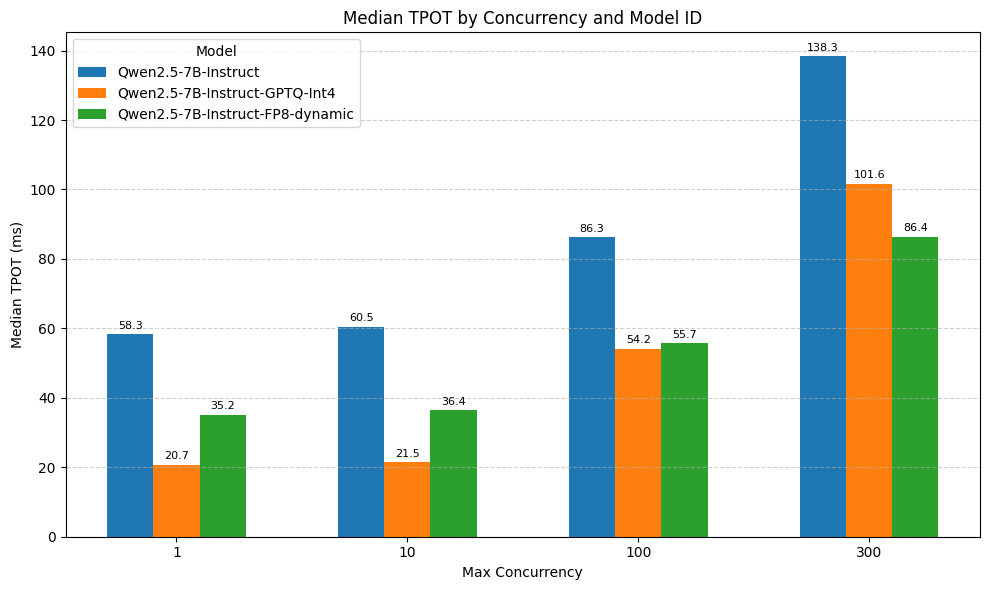

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

# Parse raw data
#raw_data = """<...your data here...>"""  # keep the full string as before
#data = [json.loads(line) for line in raw_data.strip().split('\n')]

# Organize by rate (max_concurrency)
grouped = {}
for entry in data:
    rate = entry["max_concurrency"]
    model = entry["model_id"]
    ttft = entry["median_tpot_ms"]
    if rate not in grouped:
        grouped[rate] = {}
    grouped[rate][model] = ttft

# Sort the group keys (rates) for consistent display
sorted_rates = sorted(grouped.keys())

# Unique models across all groups
all_models = sorted(set(model for group in grouped.values() for model in group))

# Prepare bar positions and heights
bar_width = 0.2
x = np.arange(len(sorted_rates))
offsets = np.linspace(-bar_width*(len(all_models)-1)/2, bar_width*(len(all_models)-1)/2, len(all_models))

plt.figure(figsize=(10, 6))

for i, model in enumerate(all_models):
    ttft_values = [grouped[rate].get(model, 0) for rate in sorted_rates]
    bar_positions = x + offsets[i]
    bars = plt.bar(bar_positions, ttft_values, bar_width, label=model.split("/")[-1])

    # Add text labels above each bar
    for pos, val in zip(bar_positions, ttft_values):
        if val > 0:
            plt.text(pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)


plt.xlabel("Max Concurrency")
plt.ylabel("Median TPOT (ms)")
plt.title("Median TPOT by Concurrency and Model ID")
plt.xticks(x, sorted_rates)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


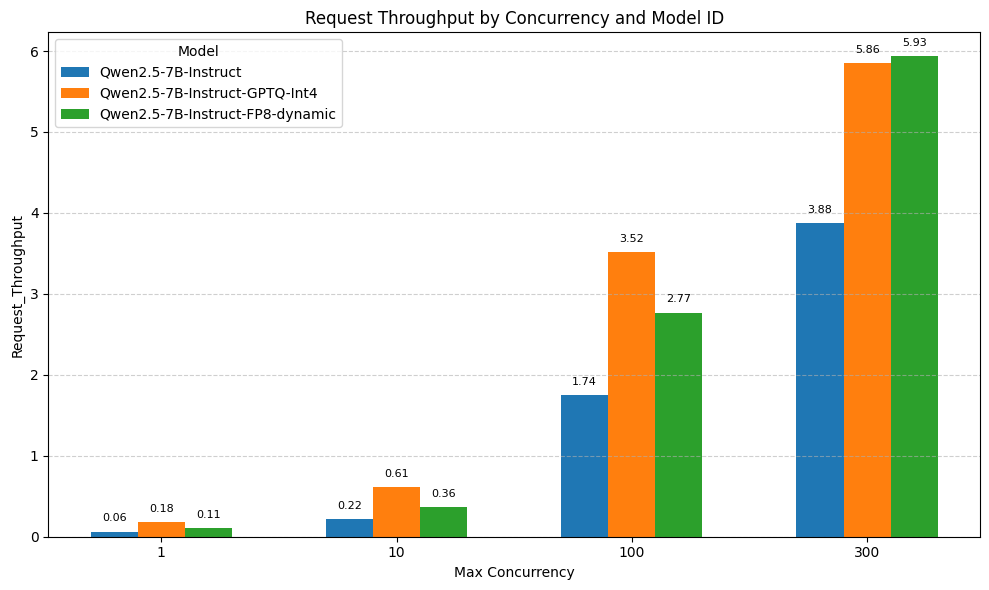

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

# Parse raw data
#raw_data = """<...your data here...>"""  # keep the full string as before
#data = [json.loads(line) for line in raw_data.strip().split('\n')]

# Organize by rate (max_concurrency)
grouped = {}
for entry in data:
    rate = entry["max_concurrency"]
    model = entry["model_id"]
    ttft = entry["request_throughput"]
    if rate not in grouped:
        grouped[rate] = {}
    grouped[rate][model] = ttft

# Sort the group keys (rates) for consistent display
sorted_rates = sorted(grouped.keys())

# Unique models across all groups
all_models = sorted(set(model for group in grouped.values() for model in group))

# Prepare bar positions and heights
bar_width = 0.2
x = np.arange(len(sorted_rates))
offsets = np.linspace(-bar_width*(len(all_models)-1)/2, bar_width*(len(all_models)-1)/2, len(all_models))

plt.figure(figsize=(10, 6))

for i, model in enumerate(all_models):
    ttft_values = [grouped[rate].get(model, 0) for rate in sorted_rates]
    bar_positions = x + offsets[i]
    bars = plt.bar(bar_positions, ttft_values, bar_width, label=model.split("/")[-1])

    # Add text labels above each bar
    for pos, val in zip(bar_positions, ttft_values):
        if val > 0:
            plt.text(pos, val + 0.1, f"{val:.2f}", ha='center', va='bottom', fontsize=8)


plt.xlabel("Max Concurrency")
plt.ylabel("Request_Throughput")
plt.title("Request Throughput by Concurrency and Model ID")
plt.xticks(x, sorted_rates)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Model")
plt.tight_layout()
plt.show()
